# Quantitative model slicing: the influence graph

A dependency graph tells you *whether* a block can affect a signal. On a closed loop the answer is always "yes, all of them" — true, and useless for deciding what to instrument, what to simplify away, or what to put in front of a reviewer. `jaxonomy.analysis.influence_graph` puts an autodiff Jacobian on every edge of that same graph, which turns the question into *how much*. By the end of this notebook you will be able to build the influence graph of any Jaxonomy model, read its weights without misreading them, take a quantitative model slice, attribute one signal's effect on another path by path, and state precisely where the method stops being trustworthy.

**Reading time:** ~35 minutes. **Runtime:** ~30 s on a laptop CPU — no GPU, no pre-computed assets, every number below is produced by a cell in this notebook.

**Prerequisites:** `DiagramBuilder` composition and `simulate` ([Primitive blocks and composability](primitives.ipynb)). Familiarity with linearization ([Linearization workflow](linearization_workflow.ipynb)) helps with §5 but is not required. No prior exposure to program slicing is assumed.

**The artifact:** one 19-block PI-controlled brushed DC motor drive, carried from beginning to end. Every physical term is its own block, so every term is its own node in the graph and we can ask about it by name.

## 1. The question a boolean dependency graph cannot answer

Here is a real engineering question. A hobby-scale motor drive misses its speed target under load, and you have a 19-block model of it. Which parts of that model actually determine the shaft speed? You want the answer because you are about to do one of three things: instrument the rig (you can afford three sensors), ship a reduced-order copy of the model to a real-time target, or convince a reviewer that a term you dropped was safe to drop.

Jaxonomy's `framework/dependency_graph.py` answers the *structural* version of that question. It knows which ports feed which, so it can tell you every block that is upstream of the shaft speed. On an open chain that is a useful answer. On a closed loop it is not, because feedback makes everything upstream of everything else. The structural answer will be "all 19 blocks", and it will be correct.

What is missing is magnitude. A wire that exists and a wire that carries something are different facts, and only the second one helps. The partial derivative $\partial y/\partial u$ is exactly the missing fact, and Jaxonomy already computes derivatives of anything in a diagram. The influence graph is those two things put together: the model's own leaf-level dependency structure, with the exact local partial derivative on every edge.

> **Note:** "Slicing" is borrowed from program analysis — Weiser's 1981 backward slice is the set of statements that can affect a value at a program point. A boolean slice over-approximates; a *quantitative* slice keeps only what carries influence above a cutoff. Shrinking that over-approximation is the whole exercise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

import jaxonomy
from jaxonomy import logging as jlog
from jaxonomy.analysis import influence_graph, influence_subgraph
from jaxonomy.diagnostics import analyze_control_oscillation, analyze_saturation
from jaxonomy.library import Adder, Constant, Gain, Integrator, LTISystem, Saturate
from jaxonomy.simulation import SimulatorOptions

jlog.set_log_level(jlog.ERROR)   # the simulator is chatty at INFO, and we run it a lot below

## 2. The plant: a PI-controlled brushed DC motor

We need a model small enough to read in full and structurally honest enough that the answer is not obvious. A brushed DC motor under PI speed control with a voltage-limited driver fits: two coupled first-order systems inside a feedback loop, with a hard nonlinearity (the driver rail) sitting in the middle of the control path.

The electrical side is a series R–L circuit driven against the back-EMF the spinning rotor generates:

$$L\,\frac{\mathrm{d}i}{\mathrm{d}t} = v - R\,i - K_e\,\omega \tag{1}$$

Dimensional check on the term that is easiest to get wrong: $[K_e\,\omega] = \mathrm{V\,s\,rad^{-1}} \cdot \mathrm{rad\,s^{-1}} = \mathrm{V}$, so the back-EMF really is a voltage subtracted from the applied one. Physically it is the motor refusing to accept current once it is already turning fast — the reason a free-running motor draws almost nothing.

The mechanical side is a torque balance on the rotor inertia:

$$J\,\frac{\mathrm{d}\omega}{\mathrm{d}t} = K_t\,i - b\,\omega - T_L - b_s\,\omega \tag{2}$$

with $[K_t\,i] = \mathrm{N\,m\,A^{-1}} \cdot \mathrm{A} = \mathrm{N\,m}$. The last term, $b_s\,\omega$, is a token stiction-compensation gain — the kind of term someone once added to a real model, with a coefficient three orders of magnitude below the viscous drag it sits next to. It is here on purpose: it is the thing a quantitative slice should throw away and a boolean slice cannot.

The controller is a PI on speed error, clipped at the driver's rail:

$$e = \omega_{\mathrm{ref}} - \omega, \qquad v = \mathrm{sat}\!\left(k_p\,e + k_i\!\int_0^t\! e\,\mathrm{d}t',\; \pm V_{\mathrm{lim}}\right) \tag{3}$$

| symbol | meaning | units | value |
|---|---|---|---|
| $R$ | armature resistance | $\Omega$ | 1.2 |
| $L$ | armature inductance | H | $2.4\times10^{-3}$ |
| $K_t$ | torque constant | N m A$^{-1}$ | 0.042 |
| $K_e$ | back-EMF constant | V s rad$^{-1}$ | 0.042 |
| $J$ | rotor + load inertia | kg m$^2$ | $1.1\times10^{-4}$ |
| $b$ | viscous damping | N m s rad$^{-1}$ | $3.0\times10^{-5}$ |
| $b_s$ | stiction-compensation gain | N m s rad$^{-1}$ | $1\times10^{-8}$ |
| $V_{\mathrm{lim}}$ | driver voltage rail | V | 12 |
| $T_L$ | constant load torque | N m | 0.010 |
| $\omega_{\mathrm{ref}}$ | speed setpoint | rad s$^{-1}$ | 220 |
| $k_p,\;k_i$ | PI gains | V s rad$^{-1}$, V rad$^{-1}$ | 0.02, 0.6 |

Two time constants fall out of that table, and they will matter a great deal in §5: the electrical $L/R = 2.0$ ms and the mechanical $J/b = 3.7$ s. That is a stiffness ratio of about 1800 inside a 19-block model.

In [2]:
# --- Motor and controller parameters (a small hobby-scale brushed DC motor) ---
R_ARM = 1.2        # armature resistance [ohm]
L_ARM = 2.4e-3     # armature inductance [H]
K_T = 0.042        # torque constant [N*m/A]
K_E = 0.042        # back-EMF constant [V*s/rad]
J_ROT = 1.1e-4     # rotor + load inertia [kg*m^2]
B_VISC = 3.0e-5    # viscous damping [N*m*s/rad]
B_STICTION = 1e-8  # token stiction-compensation gain: real structure, no influence
V_LIMIT = 12.0     # driver voltage rail [V]
T_LOAD = 0.010     # constant load torque [N*m]
W_REF = 220.0      # speed setpoint [rad/s]
KP, KI = 0.02, 0.6 # PI gains

T_END = 1.5        # simulated horizon [s]
N_SNAPSHOTS = 8    # operating points used by trajectory mode

TAU_ELECTRICAL = L_ARM / R_ARM   # 2.0 ms
TAU_MECHANICAL = J_ROT / B_VISC  # 3.7 s
print(f"electrical time constant L/R = {TAU_ELECTRICAL * 1e3:.2f} ms")
print(f"mechanical time constant J/b = {TAU_MECHANICAL:.2f} s")
print(f"stiffness ratio              = {TAU_MECHANICAL / TAU_ELECTRICAL:.0f}")

electrical time constant L/R = 2.00 ms
mechanical time constant J/b = 3.67 s
stiffness ratio              = 1833


We build the loop out of primitives — one block per physical term — rather than wrapping the motor in a single custom `LeafSystem`. Both are legitimate, and the trade-off is the usual one: a custom block encapsulates the physics and keeps the diagram small, while a primitives composition makes every term separately addressable. Here the second is what we want, because *the terms are the answer*: we are going to ask whether the stiction gain matters, and it can only be answered by name if it is its own block.

The controller is a PI assembled from `Gain` + `Integrator` + `Adder` rather than the library `PID` block, for a reason specific to this analysis. `PID` carries a derivative-filter state that is identically zero when $k_d = 0$, and §3 explains why a signal pinned at zero is the one thing that makes a relative weight meaningless.

In [3]:
def make_motor_loop(kp: float = KP, v_limit: float = V_LIMIT):
    """PI-controlled DC motor speed loop, one block per physical term."""
    builder = jaxonomy.DiagramBuilder()

    # --- Controller: e = w_ref - w, then kp*e + ki*integral(e), then the rail (eq. 3)
    reference = builder.add(Constant(W_REF, name="w_ref"))
    speed_error = builder.add(Adder(2, operators="+-", name="speed_error"))
    proportional = builder.add(Gain(kp, name="kp"))
    integral_gain = builder.add(Gain(KI, name="ki"))
    integral = builder.add(Integrator(0.0, name="integral"))
    command = builder.add(Adder(2, operators="++", name="v_cmd"))
    driver = builder.add(
        Saturate(upper_limit=v_limit, lower_limit=-v_limit, name="driver")
    )

    # --- Electrical: L*di/dt = v - R*i - Ke*w   (eq. 1)
    resistive_drop = builder.add(Gain(R_ARM, name="R_drop"))
    back_emf = builder.add(Gain(K_E, name="back_emf"))
    voltage_balance = builder.add(Adder(3, operators="+--", name="v_balance"))
    inductance = builder.add(Gain(1.0 / L_ARM, name="inv_L"))
    current = builder.add(Integrator(0.0, name="current"))

    # --- Mechanical: J*dw/dt = Kt*i - b*w - T_load - b_s*w   (eq. 2)
    motor_torque = builder.add(Gain(K_T, name="Kt"))
    drag = builder.add(Gain(B_VISC, name="drag"))
    stiction = builder.add(Gain(B_STICTION, name="stiction"))
    load = builder.add(Constant(T_LOAD, name="load_torque"))
    torque_balance = builder.add(Adder(4, operators="+---", name="torque_balance"))
    inertia = builder.add(Gain(1.0 / J_ROT, name="inv_J"))
    speed = builder.add(Integrator(0.0, name="speed"))

    # Control path. connect(source_output_port, destination_input_port).
    builder.connect(reference.output_ports[0], speed_error.input_ports[0])
    builder.connect(speed.output_ports[0], speed_error.input_ports[1])
    builder.connect(speed_error.output_ports[0], proportional.input_ports[0])
    builder.connect(speed_error.output_ports[0], integral_gain.input_ports[0])
    builder.connect(integral_gain.output_ports[0], integral.input_ports[0])
    builder.connect(proportional.output_ports[0], command.input_ports[0])
    builder.connect(integral.output_ports[0], command.input_ports[1])
    builder.connect(command.output_ports[0], driver.input_ports[0])

    # Electrical loop
    builder.connect(driver.output_ports[0], voltage_balance.input_ports[0])
    builder.connect(current.output_ports[0], resistive_drop.input_ports[0])
    builder.connect(resistive_drop.output_ports[0], voltage_balance.input_ports[1])
    builder.connect(speed.output_ports[0], back_emf.input_ports[0])
    builder.connect(back_emf.output_ports[0], voltage_balance.input_ports[2])
    builder.connect(voltage_balance.output_ports[0], inductance.input_ports[0])
    builder.connect(inductance.output_ports[0], current.input_ports[0])

    # Mechanical loop
    builder.connect(current.output_ports[0], motor_torque.input_ports[0])
    builder.connect(motor_torque.output_ports[0], torque_balance.input_ports[0])
    builder.connect(speed.output_ports[0], drag.input_ports[0])
    builder.connect(drag.output_ports[0], torque_balance.input_ports[1])
    builder.connect(load.output_ports[0], torque_balance.input_ports[2])
    builder.connect(speed.output_ports[0], stiction.input_ports[0])
    builder.connect(stiction.output_ports[0], torque_balance.input_ports[3])
    builder.connect(torque_balance.output_ports[0], inertia.input_ports[0])
    builder.connect(inertia.output_ports[0], speed.input_ports[0])

    return builder.build(name="motor_loop")


def step_response(diagram, context, t_end: float = T_END):
    """Closed-loop step from rest, recording the four signals we plot."""
    return jaxonomy.simulate(
        diagram,
        context,
        (0.0, t_end),
        options=SimulatorOptions(rtol=1e-8, atol=1e-10),
        recorded_signals={
            "w": diagram["speed"].output_ports[0],
            "i": diagram["current"].output_ports[0],
            "v_cmd": diagram["v_cmd"].output_ports[0],
            "v_drv": diagram["driver"].output_ports[0],
        },
    )


diagram = make_motor_loop()
context = diagram.create_context()
results = step_response(diagram, context)

t = np.asarray(results.time)
w = np.asarray(results.outputs["w"])
i_arm = np.asarray(results.outputs["i"])
v_cmd = np.asarray(results.outputs["v_cmd"])
v_drv = np.asarray(results.outputs["v_drv"])

print(f"blocks in the model            : {len(diagram.leaf_systems)}")
print(f"shaft speed at t = {T_END:.1f} s        : {w[-1]:.4f} rad/s")
print(f"steady-state error vs setpoint : {W_REF - w[-1]:.2e} rad/s")

blocks in the model            : 19
shaft speed at t = 1.5 s        : 220.0000 rad/s
steady-state error vs setpoint : -2.35e-06 rad/s


Before analysing the model we check that it behaves like a motor. The integral term should drive the steady-state speed error to zero against the constant load torque, and setting $\dot\omega = 0$ in equation (2) gives the current the machine must hold:

$$i_\infty = \frac{T_L + (b + b_s)\,\omega_{\mathrm{ref}}}{K_t} \tag{2a}$$

— the load torque *plus* the viscous drag at 220 rad/s, which is a third of the total and easy to forget.

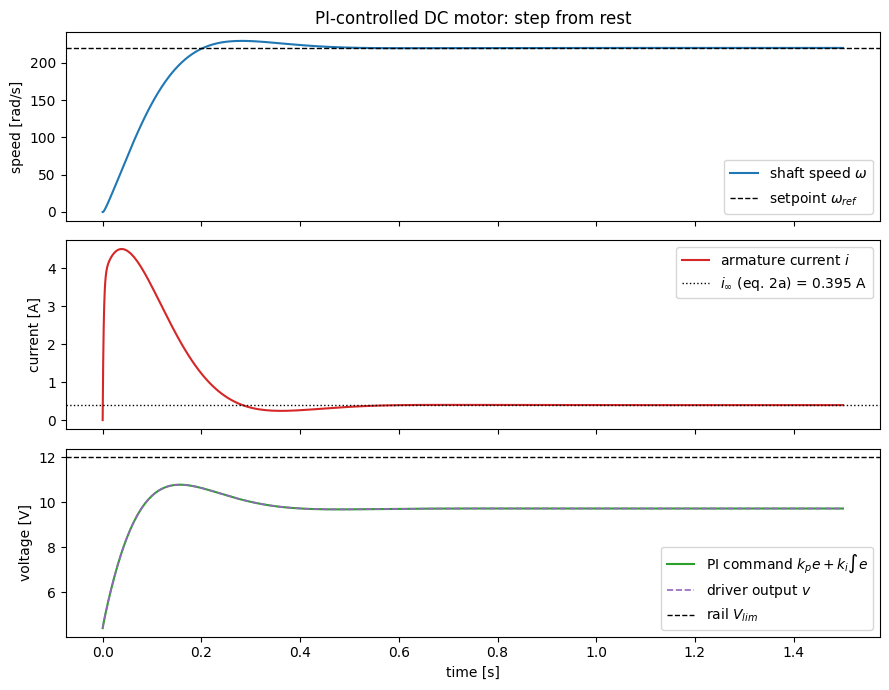

steady-state current : 0.3953 A   (analytic eq. 2a = 0.3953 A)
peak speed           : 229.4 rad/s (4.3% overshoot)
peak PI command      : 10.77 V against a 12 V rail


In [4]:
I_HOLD = (T_LOAD + (B_VISC + B_STICTION) * W_REF) / K_T   # eq. 2a

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

axes[0].plot(t, w, color="tab:blue", label="shaft speed $\\omega$")
axes[0].axhline(W_REF, color="k", ls="--", lw=1, label="setpoint $\\omega_{ref}$")
axes[0].set_ylabel("speed [rad/s]")
axes[0].legend(loc="lower right")
axes[0].set_title("PI-controlled DC motor: step from rest")

axes[1].plot(t, i_arm, color="tab:red", label="armature current $i$")
axes[1].axhline(I_HOLD, color="k", ls=":", lw=1,
                label=f"$i_\\infty$ (eq. 2a) = {I_HOLD:.3f} A")
axes[1].set_ylabel("current [A]")
axes[1].legend(loc="upper right")

axes[2].plot(t, v_cmd, color="tab:green", label="PI command $k_p e + k_i \\int e$")
axes[2].plot(t, v_drv, color="tab:purple", lw=1.2, ls="--", label="driver output $v$")
axes[2].axhline(V_LIMIT, color="k", ls="--", lw=1, label="rail $V_{lim}$")
axes[2].set_ylabel("voltage [V]")
axes[2].set_xlabel("time [s]")
axes[2].legend(loc="lower right")

fig.tight_layout()
plt.show()

print(f"steady-state current : {i_arm[-1]:.4f} A   (analytic eq. 2a = {I_HOLD:.4f} A)")
print(f"peak speed           : {w.max():.1f} rad/s "
      f"({100 * (w.max() / W_REF - 1):.1f}% overshoot)")
print(f"peak PI command      : {v_cmd.max():.2f} V against a {V_LIMIT:.0f} V rail")

*Figure 1: closed-loop step response. Top — shaft speed (blue) rises to the 220 rad/s setpoint (dashed) with about 4% overshoot and settles by ~0.6 s. Middle — armature current (red) peaks near 4.4 A during the acceleration and settles on the analytic hold current $i_\infty$ of equation (2a) (dotted). Bottom — the PI command (green) and the driver output (purple dashed) coincide throughout: with $k_p = 0.02$ the command peaks at 10.8 V, under the 12 V rail (dashed black), so the driver never saturates in this baseline run. We deliberately break that in §7.*

The steady-state current matches equation (2a) to four digits and the speed error is $\sim10^{-6}$ rad/s, which is the integral action doing its job. The model is a motor. Now the question.

### The boolean answer

`InfluenceGraph.structural_slice` computes the classical answer from the model's declared connectivity alone — no Jacobians involved, so it stays a genuine over-approximation even where a derivative could not be taken. It is the baseline the weighted slice has to beat.

In [5]:
at_rest = influence_graph(diagram, context)        # built at t = 0; §3 returns to this
structural = at_rest.structural_slice("speed:xc")  # "what can reach the shaft speed?"

print(f"blocks structurally upstream of the shaft speed: "
      f"{len(structural)} of {at_rest.n_blocks}")
print(", ".join(structural))

blocks structurally upstream of the shaft speed: 19 of 19
Kt, R_drop, back_emf, current, drag, driver, integral, inv_J, inv_L, ki, kp, load_torque, speed, speed_error, stiction, torque_balance, v_balance, v_cmd, w_ref


All 19 of 19. That is the correct answer to the wrong question, and it is not a defect in the structural analysis — in a closed loop every block genuinely is upstream of every other block, the setpoint included. Any method that only knows about connectivity stops here.

Note the node id `"speed:xc"`. Nodes in the influence graph are *signals*, not blocks: one per leaf input port, one per leaf output port, and one per continuous (`xc`) or discrete (`xd`) state group. `speed:xc` is the continuous state of the block named `speed` — the shaft speed itself. Ids are built from the block's name path and the port name, so they survive a rebuild of the model and can be quoted in a report. `InfluenceGraph.resolve` also accepts a port object or any unambiguous fragment, so `graph.slice("speed:xc")` and `graph.slice(diagram["speed"].output_ports[0])` are both valid ways to name a target — they name *different* nodes, the state and the output port that reads it, which on an `Integrator` differ by one edge.

## 3. What the influence graph adds, and what its numbers mean

The construction is simple to state. For every leaf block, evaluate the four local Jacobian blocks an engineer would call $A$, $B$, $C$, $D$ — but for that block *alone*, with its inputs pinned at their operating-point values:

$$\frac{\partial y_i}{\partial u_j},\qquad \frac{\partial y_i}{\partial x},\qquad \frac{\partial \dot x}{\partial u_j},\qquad \frac{\partial \dot x}{\partial x}$$

Each becomes an edge, with the discrete-time counterparts computed the same way so a discrete filter is weighted rather than dropped. Wires between blocks become identity edges. The composition — the whole-model Jacobian — is then carried by *paths* through the graph rather than by any single edge, which is the point: a path is something you can name, rank, and explain.

### Weights are elasticities, and that is what makes them multiply

Storing the raw partial derivative on each edge has a problem: the units differ everywhere. On this model one edge is volts per amp, another is rad s$^{-2}$ per N m, and comparing them is meaningless. So the default normalization is *relative*: for an edge whose local Jacobian block is $J$, running from signal $v$ to signal $z$,

$$w_{ij} = J_{ij}\,\frac{s(v)_j}{s(z)_i}, \qquad s(\cdot) = \text{operating-point magnitude, floored at }\ \texttt{scale\_floor} \tag{4}$$

This is dimensionless, so an electrical edge and a thermal edge land on the same axis. But the load-bearing property is not comparability, it is that these weights **telescope**. Along a path $v_0 \to v_1 \to \cdots \to v_n$ of scalar signals, the product is

$$\prod_{k=1}^{n} \frac{\partial v_k}{\partial v_{k-1}}\cdot\frac{|v_{k-1}|}{|v_k|} \;=\; \frac{\partial v_n}{\partial v_0}\cdot\frac{|v_0|}{|v_n|} \tag{5}$$

because every intermediate magnitude appears once in a numerator and once in a denominator. The product of the weights along a path *is* the relative end-to-end sensitivity along that path: a 1% change at the origin produces a $(\prod w)$% change at the destination. That is what licenses reading a path product as "this route carries this much of the influence". Pass `normalize="none"` and you get raw partials instead, in which case a path product is literally $\partial v_n / \partial v_0$ in the model's own units — which is exactly what we want for the validation in §4.

The floor in equation (4) is the one thing to watch. Dividing by $|v|$ is fine until $|v| = 0$, and control loops are full of signals that sit at zero: an error at steady state, every state at $t = 0$.

In [6]:
floored = at_rest.nodes_at_scale_floor()
print(f"{len(floored)} of {at_rest.graph.number_of_nodes()} signals sit at the scale "
      f"floor at t = 0:")
print("  " + ", ".join(floored[:6]) + f", ... (+{len(floored) - 6} more)")

23 of 46 signals sit at the scale floor at t = 0:
  Kt:in:in_0, Kt:out:out_0, R_drop:in:in_0, R_drop:out:out_0, back_emf:in:in_0, back_emf:out:out_0, ... (+17 more)


Twenty-three of the forty-six signals, because at $t = 0$ the motor is at rest and every current, speed, torque and back-EMF in the model is exactly zero. Building the graph *here* would rank blocks by an arbitrary floor — and those weights are large, so they would dominate the ranking rather than merely perturb it.

There are three ways out: analyse at a settled operating point, raise `scale_floor`, or use `at="trajectory"`, which takes several snapshots along a simulated run and normalizes every snapshot by the *largest* magnitude each signal reaches over the whole run. Trajectory mode is the right default for a manoeuvre — "how much does this matter over the step response" is the question we actually have — so that is what we use from here on. It also stores a per-edge weight *profile*, which §7 needs.

In [7]:
graph = influence_graph(
    diagram, context,
    at="trajectory", results=results, n_snapshots=N_SNAPSHOTS,
    tau=0.1,           # seconds; §5 is entirely about this number
)
print(graph.summary())

InfluenceGraph for motor_loop
  19 blocks, 46 nodes, 54 edges
  at=trajectory  normalize=relative  tau=0.1 s  scale_floor=1e-06
  8 snapshots over [0, 1.5] s, reduce=max
  1 hybrid blocks (weights valid for the current mode only): driver


Nineteen blocks, 46 signal nodes, 54 edges — and one honesty label already. The `driver` block is flagged **hybrid**, because `Saturate` carries zero-crossing events: its Jacobian is exact for the mode it is currently in and says nothing about the others. Nothing sits at the scale floor now, because the trajectory-wide normalizer uses each signal's peak magnitude rather than its value at one instant.

The node and edge attributes below are how you drill down when a scalar weight is not enough:

In [8]:
edge = graph.graph.edges["back_emf:in:in_0", "back_emf:out:out_0"]
print("edge  back_emf:in:in_0 -> back_emf:out:out_0")
print(f"  kind           : {edge['kind']}")
print(f"  jacobian       : {edge['jacobian'].reshape(-1)}   (raw dy/du, i.e. K_e)")
print(f"  relative       : {edge['relative'].reshape(-1)}   (elasticity, eq. 4)")
print(f"  local_gradient : {edge['local_gradient']}")
print(f"  profile        : {np.array2string(edge['profile'], precision=3)}")

node = graph.graph.nodes["speed:xc"]
print("\nnode  speed:xc")
print(f"  kind  : {node['kind']} ({node['state_kind']})    block: {node['block']}"
      f"    size: {node['size']}")
print(f"  value : {node['value']}   (peak magnitude over the trajectory)")

edge  back_emf:in:in_0 -> back_emf:out:out_0
  kind           : feedthrough
  jacobian       : [0.042]   (raw dy/du, i.e. K_e)
  relative       : [1.]   (elasticity, eq. 4)
  local_gradient : True
  profile        : [1. 1. 1. 1. 1. 1. 1. 1.]

node  speed:xc
  kind  : state (xc)    block: speed    size: 1
  value : [221.98234116]   (peak magnitude over the trajectory)


The relative weight of a pure `Gain` block is 1 regardless of the gain, which is exactly right and worth pausing on: a gain of $K_e$ maps a 1% change in its input to a 1% change in its output, whatever $K_e$ is. Elasticity measures *proportional* transmission. The gain's actual magnitude shows up where it belongs — at the summing junction downstream, where a large term dominates a small one.

## 4. Validation: the weights are the real derivatives

Before trusting a ranking we check the arithmetic against something independent. The cleanest test on this model is the load-torque sensitivity of the shaft acceleration, because equation (2) gives it in closed form:

$$\frac{\partial \dot\omega}{\partial T_L} = -\frac{1}{J} \tag{6}$$

We compare three numbers: that analytic value, a central difference taken *through the assembled diagram* (perturb the load signal where it arrives and re-evaluate the whole downstream chain, so nothing is checked block by block), and the influence graph's own path attribution. For this we want raw partials rather than elasticities, so `normalize="none"` — a path product is then literally $\partial \dot\omega/\partial T_L$ in rad s$^{-2}$ per N m.

In [9]:
raw = influence_graph(diagram, context, normalize="none", tau=1.0)


def shaft_acceleration(load_value: float) -> float:
    """dw/dt for a perturbed load torque, evaluated through the full diagram."""
    load_input = diagram["torque_balance"].input_ports[2]
    with load_input.fixed(jnp.asarray(load_value)):
        rate = diagram["speed"].eval_time_derivatives(context)
    return float(np.asarray(rate).reshape(()))


STEP = 1e-7
finite_difference = (
    shaft_acceleration(T_LOAD + STEP) - shaft_acceleration(T_LOAD - STEP)
) / (2 * STEP)
attribution = raw.attribute("speed:xc", "load_torque:out:out_0")

print(f"analytic  -1/J                            = {-1.0 / J_ROT:+.6f}")
print(f"central difference through the diagram    = {finite_difference:+.6f}")
print(f"influence-graph path attribution          = {attribution.total:+.6f}")
print(f"relative agreement with finite difference = "
      f"{abs(attribution.total - finite_difference) / abs(finite_difference):.2e}")
print()
print(attribution.report())

analytic  -1/J                            = -9090.909091
central difference through the diagram    = -9090.909091
influence-graph path attribution          = -9090.909091
relative agreement with finite difference = 8.73e-12

Attribution load_torque:out:out_0 -> speed:xc
  total (signed sum over paths): -9090.91
  total magnitude: 9090.91
  -9090.91
      load_torque:out:out_0 -> torque_balance:in:in_2 -> torque_balance:out:out_0 -> inv_J:in:in_0 -> inv_J:out:out_0 -> speed:in:in_0 -> speed:xc


Agreement to $\sim10^{-11}$ relative, which is the finite-difference step's own truncation error, not the graph's. The attribution finds exactly one path — the load torque reaches the shaft acceleration only through the torque balance and $1/J$ — and reports it *signed*, negative, because more load means less acceleration.

That signedness matters more than it looks. `attribute` returns the signed sum over paths, so when a source reaches a target two ways that partly cancel, the total falls far below the largest single path and you can see which pair is fighting. A boolean graph cannot express cancellation at all; a graph of magnitudes would hide it. (When a matrix-valued block sits on a path there is no single sign to report and `total` becomes `None` — §8.)

## 5. `tau` is a frequency, not a fudge factor

Here is the one convention that will mislead you if you skim it.

Most edges compose cleanly: $\partial y/\partial u$ times $\partial z/\partial y$ is $\partial z/\partial u$, and in relative terms both are dimensionless. An edge into a continuous state is different. $\partial\dot x/\partial u$ is a *rate* — state units per second per input unit — so it cannot be multiplied into a dimensionless chain as it stands. Something has to supply the seconds.

That something is `tau`. Every edge whose destination is a continuous-state derivative is scaled by it, which amounts to one explicit Euler step:

$$\Delta x \;\approx\; \tau \cdot \frac{\partial \dot x}{\partial u}\,\Delta u \tag{7}$$

and $[\tau \cdot \partial\dot x/\partial u] = \mathrm{s}\cdot\frac{[x]}{\mathrm{s}\,[u]} = [x]/[u]$ — dimensionally a plain sensitivity again, so the chain closes. A weight through an integrator therefore means "influence accumulated over $\tau$ seconds", and nothing more. (Discrete updates need no such factor: $\partial x^+_d/\partial u$ is already a state-to-state map.)

Now the part that turns `tau` from a nuisance into the most useful knob in the module. A path crossing $k$ integrators picks up $\tau^k$. Take a path of algebraic gains $g_1,\dots,g_m$ and $k$ integrators; its transfer function is

$$G(s) = \frac{\prod_j g_j}{s^k}, \qquad\text{so}\qquad |G(j\omega)| = \frac{\prod_j g_j}{\omega^k} \tag{8}$$

Set $\omega = 1/\tau$ and the right-hand side becomes $\left(\prod_j g_j\right)\tau^k$ — which is *exactly* the $\tau$-scaled path product the graph computes. `tau` is not an approximation constant. It selects the frequency at which the question is being asked, and the answer is that path's Bode magnitude there.

Let us verify that on a system whose transfer function we can write down by hand: a unit drive into a gain of 3, an integrator, a gain of 0.5, and a second integrator, so $G(s) = 1.5/s^2$.

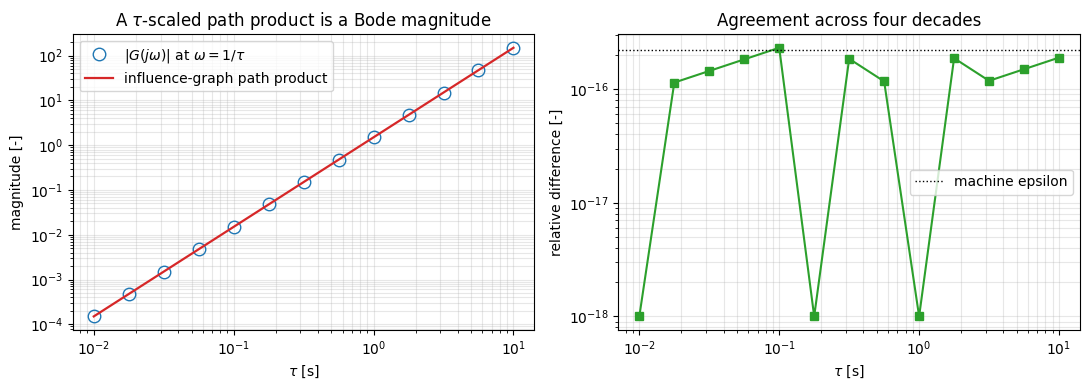

max relative difference over four decades of tau: 2.31e-16


In [10]:
GAIN_A, GAIN_B = 3.0, 0.5

builder = jaxonomy.DiagramBuilder()
drive = builder.add(Gain(1.0, name="u"))
drive.input_ports[0].fix_value(jnp.asarray(1.0))   # an exogenous input to differentiate w.r.t.
gain_a = builder.add(Gain(GAIN_A, name="ga"))
state_a = builder.add(Integrator(1.0, name="A"))
gain_b = builder.add(Gain(GAIN_B, name="gb"))
state_b = builder.add(Integrator(1.0, name="B"))
builder.connect(drive.output_ports[0], gain_a.input_ports[0])
builder.connect(gain_a.output_ports[0], state_a.input_ports[0])
builder.connect(state_a.output_ports[0], gain_b.input_ports[0])
builder.connect(gain_b.output_ports[0], state_b.input_ports[0])
double_integrator = builder.build(name="double_integrator")

TAU_SWEEP = np.logspace(-2, 1, 13)
path_products = np.array([
    influence_graph(double_integrator, normalize="none", tau=float(tau))
    .attribute("B:xc", "u:in:in_0").total
    for tau in TAU_SWEEP
])
bode_magnitude = GAIN_A * GAIN_B / (1.0 / TAU_SWEEP) ** 2   # |G(jw)| at w = 1/tau
relative_error = np.abs(path_products - bode_magnitude) / bode_magnitude

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(TAU_SWEEP, bode_magnitude, "o", ms=9, mfc="none", color="tab:blue",
               label="$|G(j\\omega)|$ at $\\omega = 1/\\tau$")
axes[0].loglog(TAU_SWEEP, path_products, "-", lw=1.6, color="tab:red",
               label="influence-graph path product")
axes[0].set_xlabel("$\\tau$ [s]")
axes[0].set_ylabel("magnitude [-]")
axes[0].set_title("A $\\tau$-scaled path product is a Bode magnitude")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

axes[1].loglog(TAU_SWEEP, np.maximum(relative_error, 1e-18), "s-", color="tab:green")
axes[1].axhline(np.finfo(float).eps, color="k", ls=":", lw=1, label="machine epsilon")
axes[1].set_xlabel("$\\tau$ [s]")
axes[1].set_ylabel("relative difference [-]")
axes[1].set_title("Agreement across four decades")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"max relative difference over four decades of tau: {relative_error.max():.2e}")

*Figure 2: left — the $\tau$-scaled path product through two integrators (red line) sits exactly on $|G(j\omega)|$ evaluated at $\omega = 1/\tau$ (blue circles) across four decades; the slope is $+2$ in $\tau$, as equation (8) requires for $k = 2$. Right — the relative difference between the two (green), at or below the level of floating-point round-off (dotted line is machine epsilon); the three points sitting on the $10^{-18}$ floor are exact bit-for-bit agreement, clipped so they can be drawn on a log axis.*

Machine precision, not "close enough". `tau` really is a frequency choice.

### What that means on a stiff model

Back to the motor, which has a 2 ms electrical loop nested inside a 3.7 s mechanical one. Because each integrator on a path contributes a factor of $\tau$, blocks at different integrator depths from the target respond differently as $\tau$ moves — and the *dominant route* can change. Let us watch that happen.

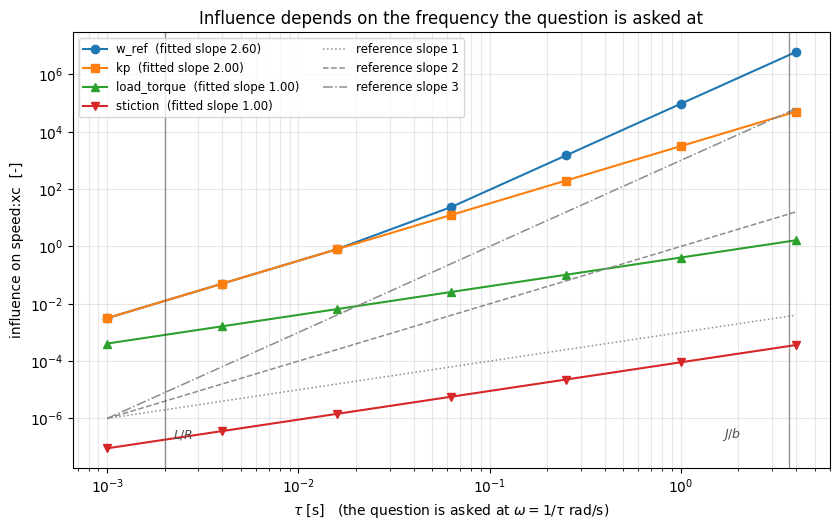

w_ref vs kp at tau = 0.001 s: 1.00x  (same route)
w_ref vs kp at tau = 3.98 s: 119.4x  (the integral branch has taken over)


In [11]:
# `scores` is keyed by *signal* (a block owns its ports and its state), so a
# block-level answer is a max over a block's nodes. `.block_scores` does that
# reduction, ranked, so we do not re-roll it in every figure below.
def block_scores(graph, target: str, threshold: float = 1e-12) -> dict:
    return graph.slice(target, threshold).block_scores


TAU_GRID = np.logspace(-3, 0.6, 7)
tau_curves = {}
for tau in TAU_GRID:
    swept = influence_graph(diagram, context, at="trajectory", results=results,
                            n_snapshots=N_SNAPSHOTS, tau=float(tau))
    for block, score in block_scores(swept, "speed:xc").items():
        tau_curves.setdefault(block, []).append(score)


def log_slope(values) -> float:
    """Least-squares slope of log(score) vs log(tau) over the sweep."""
    return float(np.polyfit(np.log(TAU_GRID), np.log(values), 1)[0])


fig, ax = plt.subplots(figsize=(8.5, 5.4))
for block, color, marker in (("w_ref", "tab:blue", "o"), ("kp", "tab:orange", "s"),
                             ("load_torque", "tab:green", "^"),
                             ("stiction", "tab:red", "v")):
    ax.loglog(TAU_GRID, tau_curves[block], marker=marker, color=color,
              label=f"{block}  (fitted slope {log_slope(tau_curves[block]):.2f})")

guide = 1e-6
for power, style in ((1, ":"), (2, "--"), (3, "-.")):
    ax.loglog(TAU_GRID, guide * (TAU_GRID / TAU_GRID[0]) ** power, style,
              color="0.55", lw=1.1, label=f"reference slope {power}")

ax.axvline(TAU_ELECTRICAL, color="0.3", lw=1, alpha=0.6)
ax.text(TAU_ELECTRICAL * 1.1, 2e-7, "$L/R$", fontsize=9, color="0.3")
ax.axvline(TAU_MECHANICAL, color="0.3", lw=1, alpha=0.6)
ax.text(TAU_MECHANICAL * 0.45, 2e-7, "$J/b$", fontsize=9, color="0.3")
ax.set_xlabel("$\\tau$ [s]   (the question is asked at $\\omega = 1/\\tau$ rad/s)")
ax.set_ylabel("influence on speed:xc  [-]")
ax.set_title("Influence depends on the frequency the question is asked at")
ax.legend(ncol=2, fontsize=8.5, loc="upper left")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

ratio = tau_curves["w_ref"][-1] / tau_curves["kp"][-1]
print(f"w_ref vs kp at tau = {TAU_GRID[0]:.3g} s: "
      f"{tau_curves['w_ref'][0] / tau_curves['kp'][0]:.2f}x  (same route)")
print(f"w_ref vs kp at tau = {TAU_GRID[-1]:.3g} s: {ratio:.1f}x  "
      f"(the integral branch has taken over)")

*Figure 3: block influence on the shaft speed as $\tau$ sweeps three and a half decades, log–log, with grey reference slopes 1, 2 and 3. `load_torque` and `stiction` reach the shaft state through a single integrator and track slope 1.00. `kp` crosses two — the current integrator and the speed integrator — and tracks slope 2.00. `w_ref` lies exactly on `kp` at small $\tau$ and bends up towards slope 3 at large $\tau$: its best route switches from the proportional branch to the integral branch, which crosses one more integrator. Its fitted slope of 2.60 is therefore a *mixture* of two regimes, not a property of any single route — the one curve in the figure whose exponent is not an integer, and the reason is visible in its curvature. Vertical grey lines mark $L/R$ and $J/b$.*

The `w_ref` curve is the whole idea in one line. At high frequency the setpoint reaches the shaft through the proportional term, and its score is identical to `kp`'s. At low frequency the integrator has time to wind up and the integral branch dominates, by a factor of 119 at the right-hand edge of the sweep. That is a fact any control engineer knows about a PI loop, recovered here from Jacobians alone, and *invisible* to a boolean dependency graph — which reports "the setpoint affects the speed" at every frequency and stops.

Two consequences to internalize, both stated in the module docstring and both easy to violate:

> **Pitfall:** an absolute threshold only reads as a percentage when $\tau$ is comparable to the time constants on the path. At $\tau = 0.1$ s on this model the strongest score is ~95, not ~1, so "keep everything above 0.01" is *not* "keep everything above 1%". Use `relative_threshold`, which scales the cutoff to the strongest contributor, when a percentage is what you mean.

> **Pitfall:** two blocks at different integrator depths are being compared through different-order transfers. That is meaningful — it is a Bode-style reading at one frequency — but it is not "fraction of the same quantity". Re-run at another $\tau$; the picture changing *is* the information.

In [12]:
absolute = graph.relative_threshold("speed:xc", fraction=0.01)
print(f"tau = {graph.tau} s: 1% of the strongest influence on speed:xc is an "
      f"absolute cutoff of {absolute:.4g}")

tau = 0.1 s: 1% of the strongest influence on speed:xc is an absolute cutoff of 0.9545


## 6. Slicing: what actually matters to the shaft speed

Now the payoff. `slice(target, threshold)` keeps every node whose own best path to the target clears the threshold, plus the hops needed to connect those nodes to the target. That second category is not padding: a relative weight is an elasticity, so a signal can pass through a nearly-cancelling junction and be amplified back afterwards, leaving a mid-route node with a small score of its own. Keeping only the influential ones would punch holes in the result and leave the subgraph disconnected.

In [13]:
quantitative = graph.slice("speed:xc", threshold=0.01)
dropped = sorted(set(structural) - set(quantitative.blocks))

print(f"boolean slice        : {len(structural):2d} of {graph.n_blocks} blocks")
print(f"1% influence slice   : {len(quantitative.blocks):2d} of {graph.n_blocks} blocks")
print(f"dropped by weighting : {', '.join(dropped) if dropped else '(none)'}")
print()
print(repr(quantitative))

boolean slice        : 19 of 19 blocks
1% influence slice   : 18 of 19 blocks
dropped by weighting : stiction

InfluenceSlice(speed:xc, threshold=0.01, 18 blocks, 43 nodes)


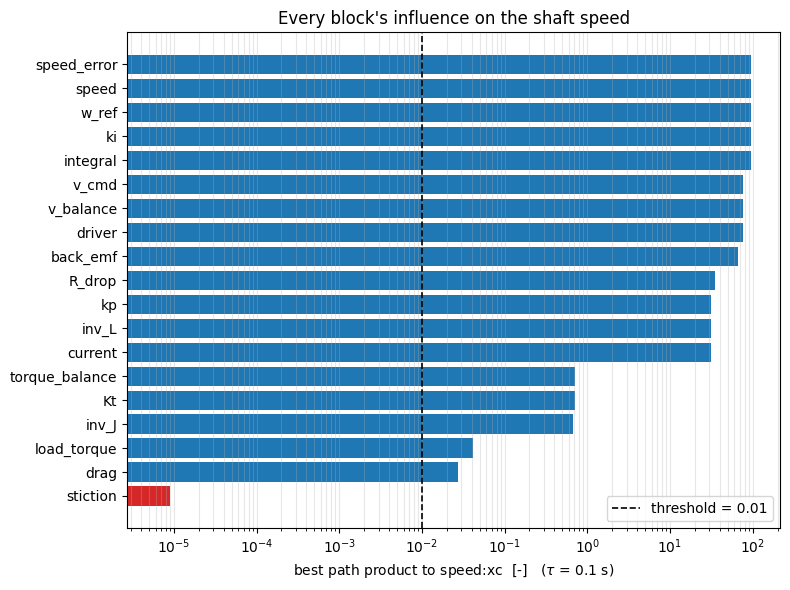

strongest : speed_error    95.45
weakest   : stiction       9.091e-06
dynamic range across the model: 1.05e+07x
stiction vs drag (its neighbour in eq. 2): 0.000333x


In [14]:
scores = graph.slice("speed:xc", 1e-12).block_scores
order = sorted(scores, key=lambda block: scores[block])
values = [scores[block] for block in order]
kept = set(quantitative.blocks)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(order, values, color=["tab:blue" if b in kept else "tab:red" for b in order])
ax.set_xscale("log")
ax.set_xlim(left=min(values) * 0.3)
ax.axvline(0.01, color="k", ls="--", lw=1.2, label="threshold = 0.01")
ax.set_xlabel(f"best path product to speed:xc  [-]   ($\\tau$ = {graph.tau:g} s)")
ax.set_title("Every block's influence on the shaft speed")
ax.legend(loc="lower right")
ax.grid(True, axis="x", which="both", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"strongest : {order[-1]:<14s} {values[-1]:.4g}")
print(f"weakest   : {order[0]:<14s} {values[0]:.4g}")
print(f"dynamic range across the model: {values[-1] / values[0]:.3g}x")
print(f"stiction vs drag (its neighbour in eq. 2): "
      f"{scores['stiction'] / scores['drag']:.3g}x")

*Figure 4: influence of each of the 19 blocks on `speed:xc`, log scale, at $\tau = 0.1$ s. Blue bars are retained by the 1% slice, red are dropped; the dashed line is the cutoff. The single dropped block is `stiction`, seven orders of magnitude below the strongest contributor and three below the viscous drag it sits next to in equation (2).*

That is the quantitative form of a dead-store warning. The stiction term is real structure — the wire exists, the block evaluates, the boolean slice is right to keep it — and it transmits nothing. `dead_edges()` reports the same class of finding at edge granularity: connections the model declares and the mathematics ignores.

The threshold is a dial, not a constant, and it is worth seeing the whole staircase rather than one setting of it.

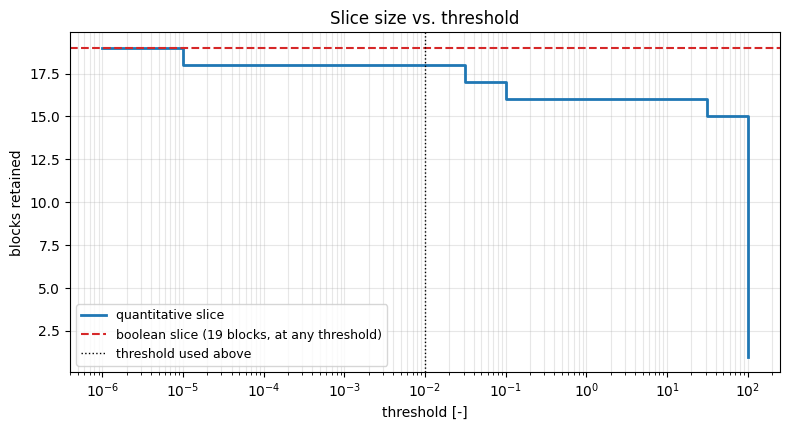

  threshold    1e-06 -> 19 blocks
  threshold    1e-02 -> 18 blocks
  threshold    1e-01 -> 16 blocks
  threshold    1e+01 -> 16 blocks
  threshold    1e+02 ->  1 blocks


In [15]:
THRESHOLDS = np.logspace(-6, 2, 17)
sizes = [len(graph.slice("speed:xc", float(threshold)).blocks)
         for threshold in THRESHOLDS]

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.step(THRESHOLDS, sizes, where="post", color="tab:blue", lw=2,
        label="quantitative slice")
ax.axhline(len(structural), color="tab:red", ls="--", lw=1.5,
           label=f"boolean slice ({len(structural)} blocks, at any threshold)")
ax.axvline(0.01, color="k", ls=":", lw=1, label="threshold used above")
ax.set_xscale("log")
ax.set_xlabel("threshold [-]")
ax.set_ylabel("blocks retained")
ax.set_title("Slice size vs. threshold")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

for threshold in (1e-6, 1e-2, 1e-1, 1e1, 1e2):
    print(f"  threshold {threshold:>8.0e} -> "
          f"{len(graph.slice('speed:xc', threshold).blocks):2d} blocks")

*Figure 5: number of blocks retained as the cutoff sweeps eight decades (blue, step), against the boolean slice (red dashed), which is 19 at every threshold because it has no threshold. The staircase is the model's influence distribution read backwards: each step down is a block whose contribution the cutoff has just passed.*

### Which route, and where the choke points are

Slicing says *what*. `dominant_paths` says *how* — it ranks the strongest routes into a target by their chain-rule products, using the model's genuine independent inputs and states as origins.

In [16]:
def blocks_along(path) -> str:
    """Collapse a signal-level path to the sequence of blocks it visits."""
    visited = []
    for node in path["nodes"]:
        block = graph.graph.nodes[node]["block"]
        if not visited or visited[-1] != block:
            visited.append(block)
    return " -> ".join(visited)


print("strongest routes into speed:xc")
for entry in graph.dominant_paths("speed:xc", k=4):
    print(f"  {entry['product']:+10.4g}   {blocks_along(entry)}")

choke = sorted({graph.graph.nodes[node]["block"]
                for node in graph.bottlenecks("speed:xc", threshold=0.01)})
print(f"\nbottleneck blocks ({len(choke)}): every influential path passes through these")
print("  " + ", ".join(choke))

strongest routes into speed:xc
       +94.6   w_ref -> speed_error -> ki -> integral -> v_cmd -> driver -> v_balance -> inv_L -> current -> Kt -> torque_balance -> inv_J -> speed
      +31.53   w_ref -> speed_error -> kp -> v_cmd -> driver -> v_balance -> inv_L -> current -> Kt -> torque_balance -> inv_J -> speed
    -0.04095   load_torque -> torque_balance -> inv_J -> speed

bottleneck blocks (10): every influential path passes through these
  Kt, current, driver, inv_J, inv_L, speed, speed_error, torque_balance, v_balance, v_cmd


The two strongest routes are the same physical chain differing in one block — one goes through `ki` and the `integral` state, the other through `kp` — and their products differ by a factor of three at this $\tau$. That is the distinction a boolean graph cannot draw, and it is precisely the distinction you need when deciding which gain to touch. The third route is the load-torque disturbance path from §4, three orders of magnitude weaker and negative.

`bottlenecks` deletes each node of the slice in turn and asks whether some origin loses its connection to the target. Ten blocks qualify here, which is the honest reading of a single-channel drive: there is no redundancy, so almost the entire forward path is a single point of failure. In an instrumentation argument these are the signals worth a sensor; in a redundancy argument they are the ones that need a second copy.

## 7. Absent is not zero

Everything so far has assumed a derivative exists and is informative. Two situations break that assumption in opposite directions, and the module's honesty depends on treating them differently.

**A derivative that cannot be taken.** A comparator's output, a quantizer's level index, an integer mode signal, an `io_callback` into external code: no useful local gradient exists. The tempting implementation emits no edge, which reads downstream as "this input does not influence that output" — a false negative, and a dangerous one. Instead the edge is emitted with `local_gradient=False` and `magnitude=nan`, traversals treat it as *unknown-but-present*, everything behind it stays in the slice, and it is listed in `InfluenceSlice.unknown_nodes`. What such a region does not get is a *ranking*: past an unmeasurable edge there is no product left to maximize, so the search switches to plain reachability and those scores are placeholders rather than measurements.

**A derivative that exists and is zero.** A saturation pinned at its rail, a quantizer between steps, a dead zone inside the zone. Here the local derivative is genuinely, exactly zero — and the block is still transmitting information, because a *finite* change in its input does change its output. The local answer is not wrong; it is answering a smaller question than the one you asked.

Both show up in one experiment. Turn the proportional gain up from 0.02 to 0.2, so that from rest the command is $k_p\,\omega_{\mathrm{ref}} = 44$ V against a 12 V rail and the driver starts hard against its limit.

In [17]:
saturated = make_motor_loop(kp=0.2)
saturated_context = saturated.create_context()
saturated_results = step_response(saturated, saturated_context)

sat_t = np.asarray(saturated_results.time)
sat_cmd = np.asarray(saturated_results.outputs["v_cmd"])
sat_drv = np.asarray(saturated_results.outputs["v_drv"])

# This notebook ships a deliberately saturated closed loop, so we check it with the
# diagnostics rather than assume it, and state the verdict either way.
print(analyze_saturation(v_drv, lower=-V_LIMIT, upper=V_LIMIT,
                         name="driver output (baseline kp=0.02)"))
print(analyze_saturation(sat_drv, lower=-V_LIMIT, upper=V_LIMIT,
                         name="driver output (aggressive kp=0.2)"))
print(analyze_control_oscillation(sat_drv, sat_t,
                                  name="driver output (aggressive kp=0.2)"))

SaturationReport(saturated=0.0%, upper=0.0%, lower=0.0%, warn=False)
SaturationReport(saturated=23.3%, upper=23.3%, lower=0.0%, warn=False)
OscillationReport(crossings/s=0.67, warn=False)


> **Note:** the 23.3% saturation on the aggressive loop is intentional — it is the phenomenon this section studies, not a tuning bug — and it is below `analyze_saturation`'s 50% warning threshold, so no warning fires. `analyze_control_oscillation` reports 0.67 sign changes per second against a 5/s bang-bang threshold, so the loop is saturated but not chattering. The baseline loop from §2 never saturates at all.

Now build the graph at $t = 0$, where the driver is pinned, and ask the same slicing question three ways.

In [18]:
local = influence_graph(saturated, saturated_context, tau=0.1)
probed = influence_graph(saturated, saturated_context, tau=0.1, probe=0.9)

local_slice = local.slice("speed:xc", 0.01)
probed_slice = probed.slice("speed:xc", 0.01)
recovered = sorted(set(probed_slice.blocks) - set(local_slice.blocks))

print(f"boolean slice           : {len(local.structural_slice('speed:xc')):2d} blocks")
print(f"exact local derivative  : {len(local_slice.blocks):2d} blocks")
print(f"with probe=0.9 (secant) : {len(probed_slice.blocks):2d} blocks")
print(f"recovered by the probe  : {', '.join(recovered)}")
print()
print("dead edges the local derivative reports:")
for entry in local.dead_edges():
    print(f"  {entry['src']} -> {entry['dst']}  "
          f"({entry['kind']}, magnitude {entry['magnitude']:g})")
print(f"\ndriver flagged hybrid: {local.graph.nodes['driver:out:out_0']['hybrid']}")

# Is the missing control path merely below the cutoff? Sweep the threshold and see.
local_sizes = {len(local.slice("speed:xc", float(th)).blocks) for th in THRESHOLDS}
probed_sizes = {len(probed.slice("speed:xc", float(th)).blocks) for th in THRESHOLDS}
print(f"\nslice size over eight decades of threshold -> local {sorted(local_sizes)}, "
      f"probed {sorted(probed_sizes)}")

boolean slice           : 19 blocks
exact local derivative  : 13 blocks
with probe=0.9 (secant) : 19 blocks
recovered by the probe  : integral, ki, kp, speed_error, v_cmd, w_ref

dead edges the local derivative reports:
  driver:in:in_0 -> driver:out:out_0  (feedthrough, magnitude 0)

driver flagged hybrid: True

slice size over eight decades of threshold -> local [13], probed [19]


Thirteen blocks against the boolean nineteen, and the six that vanish are the entire control path: `w_ref`, `speed_error`, `kp`, `ki`, `integral`, `v_cmd`. No threshold recovers them — sweeping the cutoff across eight decades leaves the count pinned at 13 — because their influence is not small, it is *exactly zero*. The derivative of a clipped signal with respect to its input is zero, so at this operating point the setpoint genuinely does not move the shaft speed, and `dead_edges` names the responsible connection outright.

`probe=0.9` re-checks every zero-derivative edge with a central-difference secant over a step of 90% of the signal's magnitude, and uses the secant when it is non-zero. The whole control path comes back. Both answers are true; they answer different questions. The local derivative answers "what moves the output *now*, infinitesimally"; the secant answers "what moves it over a step this large". The probe size is not universal — 0.9 is needed here because the 44 V command has to come back under the 12 V rail, and 0.5 would not have done it.

> **Pitfall:** the `driver` block is flagged `hybrid=True` either way, because `Saturate` carries zero-crossing events. Its Jacobian is exact for the mode it is in and says nothing at all about the others. A hybrid flag is a standing instruction to check the other modes — with `probe=`, with trajectory mode, or by rebuilding at a different operating point.

### Trajectory mode: one number per edge is sometimes a lie

The driver's edge weight is zero at $t = 0$ and non-zero once the loop comes off the rail. No single scalar can be right for both. `at="trajectory"` keeps a per-edge *profile* across snapshots and reduces it to a scalar only when queried — with `reduce="max"` by default, which never hides an influence that appears somewhere on the run.

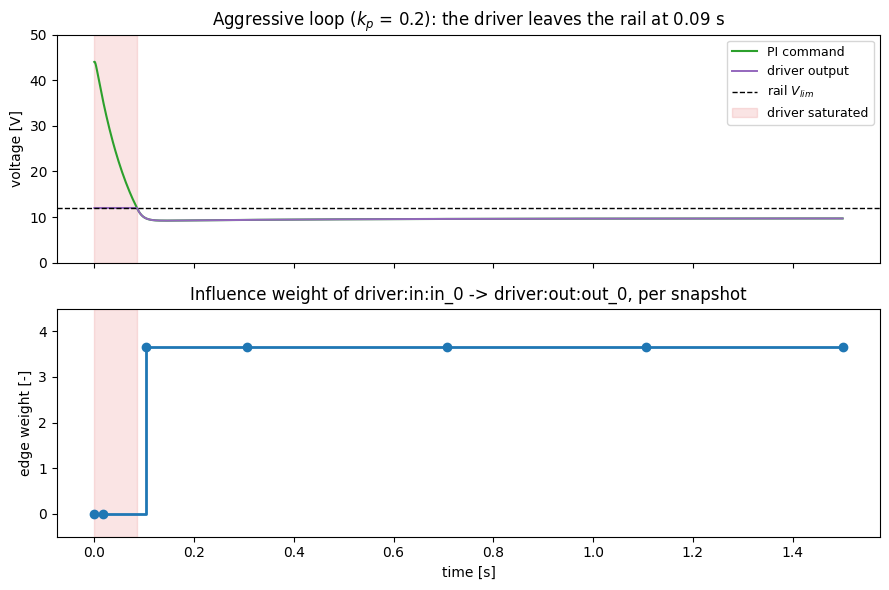

snapshot times : [0.    0.017 0.104 0.306 0.706 1.106 1.5  ]
edge profile   : [0.    0.    3.667 3.667 3.667 3.667 3.667]
1% slice from the trajectory graph: 18 of 19 blocks


In [19]:
over_time = influence_graph(saturated, saturated_context, at="trajectory",
                            results=saturated_results, n_snapshots=7, tau=0.1)
driver_edge = over_time.graph.edges["driver:in:in_0", "driver:out:out_0"]
snapshot_times = np.asarray(over_time.times)
profile = np.asarray(driver_edge["profile"])
on_rail = sat_drv >= V_LIMIT - 1e-6
leaves_rail = sat_t[np.argmax(~on_rail)]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(sat_t, sat_cmd, color="tab:green", label="PI command")
axes[0].plot(sat_t, sat_drv, color="tab:purple", lw=1.4, label="driver output")
axes[0].axhline(V_LIMIT, color="k", ls="--", lw=1, label="rail $V_{lim}$")
axes[0].fill_between(sat_t, 0, 50, where=on_rail, color="tab:red", alpha=0.12,
                     label="driver saturated")
axes[0].set_ylim(0, 50)
axes[0].set_ylabel("voltage [V]")
axes[0].set_title(f"Aggressive loop ($k_p$ = 0.2): the driver leaves the rail at "
                  f"{leaves_rail:.2f} s")
axes[0].legend(loc="upper right", fontsize=9)

axes[1].step(snapshot_times, profile, where="post", color="tab:blue", lw=2)
axes[1].plot(snapshot_times, profile, "o", color="tab:blue")
axes[1].fill_between(sat_t, -0.5, 4.5, where=on_rail, color="tab:red", alpha=0.12)
axes[1].set_ylim(-0.5, 4.5)
axes[1].set_ylabel("edge weight [-]")
axes[1].set_xlabel("time [s]")
axes[1].set_title("Influence weight of driver:in:in_0 -> driver:out:out_0, per snapshot")

fig.tight_layout()
plt.show()

print(f"snapshot times : {np.array2string(snapshot_times, precision=3)}")
print(f"edge profile   : {np.array2string(profile, precision=3)}")
print(f"1% slice from the trajectory graph: "
      f"{len(over_time.slice('speed:xc', 0.01).blocks)} of {over_time.n_blocks} blocks")

*Figure 6: top — the aggressive loop's PI command (green) against the driver output (purple) and the 12 V rail (dashed); the shaded band is the 0–0.09 s interval where the driver is clipped. Bottom — the influence weight of the driver's feedthrough edge at each of the seven snapshots: exactly zero at the two snapshots inside the band (t = 0 and 0.017 s) and 3.67 from the third (t = 0.104 s) onwards. The step in the weight lines up with the end of the shaded band, which is the point of the figure.*

With the profile in hand, `reduce="max"` puts 18 of 19 blocks back into the 1% slice, matching the baseline analysis — and it does so with evidence rather than by relaxing anything. The cost is real, though: trajectory mode re-derives the operating points by advancing the context, one `simulate` call per snapshot. On this 19-block model that is a second or two; §10 has the number at 2504 blocks, and it is not a second or two.

## 8. Vector signals report an upper bound

There is one node per state *group*, not per state component. A block with a three-component state collapses to a single node, and its edge weight has to be one number extracted from a Jacobian *matrix*. The choice is the induced $\infty$-norm — the largest absolute row sum — and the reason is that it is submultiplicative:

$$\|AB\|_\infty \le \|A\|_\infty\,\|B\|_\infty \tag{9}$$

so a path product **bounds** the true end-to-end Jacobian rather than under-stating it. The obvious alternative, the largest single entry, is not submultiplicative: chaining largest-entries can under-estimate by a factor of the inner dimension per hop, which would drop real dependencies from a slice — the one direction we must never err in.

The price is that cancellation *inside* a vector signal becomes invisible. Here is the worst case, built on purpose: a two-state plant whose input drives both states equally and whose output is their difference.

In [20]:
A = np.array([[-1.0, 0.0], [0.0, -2.0]])
B = np.array([[1.0], [1.0]])     # the input drives both states equally
C = np.array([[1.0, -1.0]])      # the output is their difference: exact cancellation
D = np.zeros((1, 1))

vector_builder = jaxonomy.DiagramBuilder()
vector_source = vector_builder.add(Constant(1.0, name="u"))
vector_plant = vector_builder.add(LTISystem(A, B, C, D, name="plant"))
vector_builder.connect(vector_source.output_ports[0], vector_plant.input_ports[0])
vector_model = vector_builder.build(name="vector_state")

vector_graph = influence_graph(vector_model, normalize="none", tau=1.0)
to_state = vector_graph.graph.edges["plant:in:in_0", "plant:xc"]
from_state = vector_graph.graph.edges["plant:xc", "plant:out:out_0"]

print(f"B block {to_state['jacobian'].tolist()}    -> scalar weight "
      f"{to_state['weight']:g}")
print(f"C block {from_state['jacobian'].tolist()}  -> scalar weight "
      f"{from_state['weight']:g}")
print(f"path product (the reported bound) : "
      f"{abs(to_state['weight'] * from_state['weight']):g}")
print(f"true composed C @ (tau*B)         : {float((C @ B).reshape(())):g}")

vector_attribution = vector_graph.attribute("plant:out:out_0", "plant:in:in_0")
print(f"\nattribute(...).total           : {vector_attribution.total}"
      f"   (None: a matrix block on the path has no single sign)")
print(f"attribute(...).total_magnitude : {vector_attribution.total_magnitude:g}")

B block [[1.0], [1.0]]    -> scalar weight 1
C block [[1.0, -1.0]]  -> scalar weight 2
path product (the reported bound) : 2
true composed C @ (tau*B)         : 0

attribute(...).total           : None   (None: a matrix block on the path has no single sign)
attribute(...).total_magnitude : 2


The graph reports 2.0 where the truth is 0.0. That is not a bug, it is the guarantee working: the bound is conservative in the safe direction, and the analysis would rather over-keep a block than silently drop one that mattered. Note also that `total` is `None` — with a matrix on the path there is no single sign to report, so the signed sum is refused rather than faked and only `total_magnitude` is offered.

When you need the per-component answer, the full Jacobian block is still on the edge: `graph.graph.edges[src, dst]["relative"]` for elasticities, `["jacobian"]` for raw partials. If the *graph itself* has to resolve components, split the block into scalar-state blocks.

## 9. Handing a bounded neighbourhood to a language model

One more use, stated carefully because it is easy to overclaim.

Asking a language model "which upstream signal dominates the shaft speed?" about a five-thousand-block model has an obvious failure mode: dump the whole structure and it does not fit in the context window; dump an arbitrary window and the answer may not be in it. The influence graph already knows which neighbours matter, so the window can be chosen by *influence* rather than by proximity in a file. `influence_subgraph` expands a bounded number of hops taking the strongest edges first, enriches the result with units and sample rates, and stops at a token budget.

In [21]:
serialized = influence_subgraph(graph, "speed:xc", budget_tokens=400, hops=6)
print(serialized["text"])
print()
print(f"estimated tokens: {serialized['estimated_tokens']} (budget 400); "
      f"edges dropped to fit: {len(serialized['dropped_edges'])}")

# influence subgraph of model 'motor_loop'
# focus: speed:xc
# weights: relative sensitivity (dimensionless); state-rate edges scaled by tau=0.1 s; evaluated at=trajectory (reduce=max)
# signals: id | value | units | sample_time | block_type
speed:xc * | 221.982 | - | continuous | Integrator
speed_error:in:in_0 | 220 | - | constant | Adder
speed_error:out:out_0 | 220 | - | constant | Adder
w_ref:out:out_0 | 220 | - | constant | Constant
v_balance:in:in_0 | 10.7433 | - | constant | Adder
v_balance:out:out_0 | 4.4 | - | constant | Adder
v_balance:in:in_1 | 4.92672 | - | constant | Adder
inv_L:in:in_0 | 4.4 | - | constant | Gain
v_balance:in:in_2 | 9.32326 | - | constant | Adder
speed_error:in:in_1 | 221.982 | - | constant | Adder
ki:in:in_0 | 220 | - | constant | Gain
kp:in:in_0 | 220 | - | constant | Gain
# edges: src -> dst | weight | kind
speed_error:in:in_0 -> speed_error:out:out_0 | +1 | feedthrough
w_ref:out:out_0 -> speed_error:in:in_0 | +1 | wire
v_balance:in:in_0 -> v_balance:ou

Three details in that output carry the weight. Edges are ranked by the influence they carry *to the focus* — an edge's own weight times the best onward path — and not by their own weight, because a nearly-cancelling summing junction has an enormous local elasticity precisely because its output is small, so a budget spent strongest-by-own-weight goes entirely to junctions that pass nothing onward. Every line is keyed by a rebuild-stable id, so an answer citing `speed:xc` can be checked against the model. And the footer distinguishes the two reasons a block can be absent: *below-cutoff* means known-to-be-negligible, which is an answer, while *dropped for budget* means unknown, which is not — treating the second as the first would be a fabrication.

**What this is worth, measured.** An offline evaluation of this capability — 24 agent runs, 268 graded items, three model scales up to 2504 blocks, with finite-difference ground truth — found that an agent given the influence context *plus* file access matched an unlimited-retrieval agent's accuracy exactly (67 of 67 for both) while reading ~342 lines instead of ~2126, and 170–450 instead of ~5010 at the 2504-block scale. The influence context alone never answered wrong across those 67 items; where it lacked the evidence it abstained, 18 times.

Read that honestly: it **tied** a grep-capable agent on accuracy. It did not beat it, and it does not let an agent answer questions it otherwise could not. What it buys is a fraction of the context budget and a strong bias against bluffing — the serialization states what it does not know, so the consumer can too. That is a real engineering property, and a modest one.

## 10. Failure modes

This module has genuine limits. Hiding them would be worse than not shipping it, because every one of them is a way to read a plausible number that is wrong.

**One `tau` for the whole graph.** `tau` scales every continuous-state-rate edge in the model, and this motor has a 2 ms electrical loop inside a 3.7 s mechanical one. No single value reads as a percentage for both, so an absolute threshold means different things on the fast and slow paths, and node scores at different integrator depths are being compared through different-order transfers. *Do:* run the analysis at several $\tau$ — Figure 3 is that sweep — and use `relative_threshold`. *Do not:* quote one $\tau$'s ranking as "the" sensitivity of a stiff model.

**State granularity is per group, not per component.** A three-state `BatteryCellECM` or a twelve-state rigid body is one node, and its edge weight is the induced $\infty$-norm — an upper bound that can be arbitrarily loose when components cancel, as §8 showed at its worst (2.0 reported for a true 0.0). *Do:* read `edge["relative"]` for the per-component block, or split the block. *Do not:* conclude that a vector state influences a target at the reported magnitude.

**The path search is bounded, not exhaustive.** Enumerating simple paths is exponential in the worst case, so `slice`, `attribute` and `dominant_paths` carry a `max_depth` (32 by default) and an expansion budget. On a densely connected model both can bite: paths longer than `max_depth` are never seen, and if the budget runs out the scores become lower bounds and contributors may be missing. The result says so — `InfluenceSlice.truncated` is set, `report()` prints a note, and `bottlenecks` warns, because a missing path is exactly what turns a non-bottleneck into an apparent single point of failure. *Do:* raise the threshold, lower `max_depth`, or focus on a smaller neighbourhood with `influence_subgraph`. *Do not:* ignore `truncated`.

**Trajectory mode costs one simulation per snapshot.** Recorded signals do not pin down every stateful leaf's state, so trajectory mode re-derives the operating points by advancing the context: $k+1$ `simulate` calls for $k$ snapshots. `simulate` has a fixed per-call setup cost that scales with block count and dominates the integration — a 1 µs span costs about the same as a 4 s one — so the snapshots, not the Jacobians, set the price. Building at a single operating point measures 0.4 s at 129 blocks, 0.9 s at 629 and 3.8 s at 2504, with every query then running in well under a second; trajectory mode at `n_snapshots=6` and 2504 blocks is roughly eleven minutes. *Do:* use operating-point mode on large models and accept the loss of the per-edge profile.

**Everything is local.** Each weight is a derivative at an operating point. It says nothing about behaviour a finite distance away, which is why `probe=` exists and why a hybrid block's weights describe one mode only. For a global answer over a parameter distribution this is the wrong tool, and `jaxonomy.uq` (Sobol indices, Morris screening) is the right one.

**Relative weights need a non-zero operating point.** Twenty-three of this model's 46 signals sit at exactly zero at $t = 0$; their elasticities come from `scale_floor`, not from the model, and they are *large*, so they dominate any ranking rather than merely perturbing it. `nodes_at_scale_floor()` names them. *Do:* analyse at a settled point, use trajectory mode, raise the floor, or switch to `normalize="none"`.

## 11. Exercises

1. **(Easy, code.)** `B_STICTION` is $10^{-8}$ and the 1% slice drops it. Rebuild the model with progressively larger values and find the one at which `stiction` re-enters the slice at $\tau = 0.1$ s. Check the answer against Figure 4 — the stiction bar has to climb past the dashed line, and its score should scale linearly with the gain.

2. **(Medium, conceptual.)** Re-run §6's slice at `tau=TAU_ELECTRICAL` (2 ms). Predict *before running* which blocks leave, using the slope argument behind Figure 3: a block $k$ integrators from the target scales as $\tau^k$, so shrinking $\tau$ penalizes deep blocks hardest. Then run it, and explain any block you got wrong.

3. **(Medium, code + interpretation.)** Rebuild Figure 4 with `normalize="none"`. `inv_L` has a raw gain of $1/L \approx 417$ and will jump up the ranking; `w_ref` will fall. Which of the two rankings answers "where should I put my three sensors", and which answers "which coefficient is numerically largest"? They are not the same question.

4. **(Hard, code + prediction.)** Replace the `Saturate` driver with a `Quantizer` (from `jaxonomy.library.nonlinearities`) at a coarse resolution. Predict, before running, what `dead_edges()`, `local_gradient`, `InfluenceSlice.unknown_nodes` and `probe=` will each report — a quantizer is *flat between steps*, which is a different failure from a saturation *at its rail*. Then check. Which of the two does the graph flag `hybrid`, and why?

5. **(Open-ended.)** Take a model of your own with at least a hundred blocks. Build the graph at a settled operating point (not at $t = 0$), take a 1% slice to a signal you care about, and compare it against your own intuition about which subsystems matter. Where the graph disagrees with you, work through the checklist in §10 before concluding that the graph is wrong: check `nodes_at_scale_floor()`, check whether `truncated` is set, check the `tau` you chose against the time constants on the paths involved, and check whether a vector state is inflating a bound. Report what the disagreement turned out to be.

## 12. Key takeaways

- A boolean dependency graph answers "can this reach that"; on a closed loop the answer is always yes. Putting an autodiff Jacobian on every edge turns it into "how much", and the answer stops being trivial: 18 blocks instead of 19 here, and the one dropped is the one that deserved to be.
- Relative (elasticity) weights are the default because they **telescope**: the product along a path *is* the relative end-to-end sensitivity, so a path product is a quantity you can rank and quote. `normalize="none"` gives raw partials, which is what validation wants — here they matched a central difference through the whole diagram to $10^{-11}$.
- `tau` is a frequency, not a fudge factor. A path crossing $k$ integrators scales as $\tau^k$, which is exactly that path's transfer magnitude at $\omega = 1/\tau$ — verified to machine precision across four decades. Re-run at several $\tau$; the picture changing is the information.
- Nothing that cannot be differentiated is silently zeroed. Unmeasurable edges are labelled and kept, hybrid blocks are flagged, and `probe=` recovers a connection whose *local* derivative is honestly zero — a saturation at its rail transmits nothing infinitesimally and a great deal over a finite step.
- The conservative choices all point the same way: vector signals report an upper bound, `reduce="max"` never hides a transient influence, and a truncated search says so. The analysis would rather over-keep than silently drop.

## Next steps

- [Linearization workflow](linearization_workflow.ipynb) — `findop`, `linearize`, and Bode / Nyquist / pole-zero analysis; the frequency-domain view that §5's $\tau$ sweep is a graph-shaped cousin of.
- [Aleatoric vs epistemic uncertainty (Sobol)](aleatoric_vs_epistemic_uq.ipynb) — global sensitivity over a parameter distribution, the right tool when "local at an operating point" is not enough.
- [Reproducibility manifest](reproducibility_manifest.ipynb) — the provenance side of shipping an analysis that someone else has to trust.
- `docs/examples/influence_graph_model_slicing.py` — the same material as a runnable script, with the finite-difference cross-check as an assertion rather than a figure.

## References

1. M. Weiser, "Program slicing," *Proc. 5th Int. Conf. on Software Engineering* (ICSE), 1981, pp. 439–449. The origin of backward slicing; the boolean over-approximation this notebook shrinks.
2. F. Tip, "A survey of program slicing techniques," *Journal of Programming Languages*, 3(3), 1995, pp. 121–189. Survey of the static and dynamic slicing landscape.
3. S. J. Mason, "Feedback theory — further properties of signal flow graphs," *Proc. IRE*, 44(7), 1956, pp. 920–926. Forward paths and loop gains on a weighted graph; the reason `slice` enumerates *simple* paths rather than walks.
4. A. Griewank and A. Walther, *Evaluating Derivatives: Principles and Techniques of Algorithmic Differentiation*, 2nd ed., SIAM, 2008. The chain rule on a computational graph, which is what an edge weight is.
5. A. Saltelli et al., *Global Sensitivity Analysis: The Primer*, Wiley, 2008. Local versus global sensitivity; the framing behind §10's "everything is local" caveat.